## Is it a bird?

In [3]:
#NB: Kaggle requires phone verification to use the internet or a GPU. If you haven't done that yet, the cell below will fail
#    This code is only here to check that your internet is enabled. It doesn't do anything else.
#    Here's a help thread on getting your phone number verified: https://www.kaggle.com/product-feedback/135367

import socket,warnings
try:
    socket.setdefaulttimeout(1)
    socket.socket(socket.AF_INET, socket.SOCK_STREAM).connect(('1.1.1.1', 53))
except socket.error as ex: raise Exception("STOP: No internet. Click '>|' in top right and set 'Internet' switch to on")

In [4]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [3]:
# It's a good idea to ensure you're running the latest version of any libraries you need.
# `!pip install -Uqq <libraries>` upgrades to the latest version of <libraries>
# NB: You can safely ignore any warnings or errors pip spits out about running as root or incompatibilities
import os
iskaggle = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '')

if iskaggle:
    !pip install -Uqq fastai 'duckduckgo_search>=6.2'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 46.3 MB/s eta 0:00:00a 0:00:01


In [6]:
# !pip install torch==2.2.0 torchvision==0.17.0 --index-url https://download.pytorch.org/whl/cu118

In 2015 the idea of creating a computer system that could recognise birds was considered so outrageously challenging that it was the basis of [this XKCD joke](https://xkcd.com/1425/):

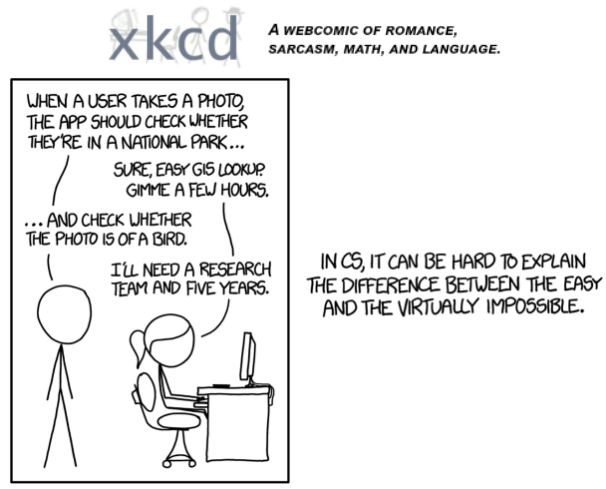

But today, we can do exactly that, in just a few minutes, using entirely free resources!

The basic steps we'll take are:

1. Use DuckDuckGo to search for images of "bird photos"
1. Use DuckDuckGo to search for images of "forest photos"
1. Fine-tune a pretrained neural network to recognise these two groups
1. Try running this model on a picture of a bird and see if it works.

## Step 1: Download images of birds and non-birds

In [12]:
# from duckduckgo_search import DDGS #DuckDuckGo has changed the api so we need to update 
# from fastcore.all import *

# def search_images(keywords, max_images=200): return L(DDGS().images(keywords, max_results=max_images)).itemgot('image')
# import time, json

In [3]:
import os
# print(os.getenv("SERPAPI_KEY"))
api_key=os.getenv("SERPAPI_KEY")


In [ ]:
# from kaggle_secrets import UserSecretsClient

# user_secrets = UserSecretsClient()
# api_key = user_secrets.get_secret("YOUR_SERPAPI_KEY")
# print(api_key)

ModuleNotFoundError: No module named 'kaggle_secrets'

In [4]:
import requests

def search_images(term, max_images=10, api_key=api_key):
    resp = requests.get("https://serpapi.com/search", params={
        "engine": "google_images",
        "q": term,
        "api_key": api_key,
        "num": max_images,
    })
    results = resp.json().get("images_results", [])
    return [r["original"] for r in results[:max_images]]


Let's start by searching for a bird photo and seeing what kind of result we get. We'll start by getting URLs from a search:

In [5]:
#NB: `search_images` depends on duckduckgo.com, which doesn't always return correct responses.
#    If you get a JSON error, just try running it again (it may take a couple of tries).
urls = search_images('bird photos', max_images=1)
urls[0]

'https://academy.allaboutbirds.org/wp-content/uploads/2015/07/Painted_Bunting_male_Birdhsare_Tim_Hopwood.jpg'

In [6]:
# urls = [
#     'https://birdwatchinghq.com/wp-content/uploads/2022/08/european-birds-featured-1.jpg',  # swap with actual bird URLs
#     'https://happybirding.com/wp-content/uploads/2023/04/Baltimore-Oriole.png',
# ]
# forest_urls = [
#     'https://wildlifeinformer.com/wp-content/uploads/2023/04/boreal-forest.jpg',
#     'https://wallpaperaccess.com/full/773426.jpg'
# ]

...and then download a URL and take a look at it:

Matplotlib is building the font cache; this may take a moment.


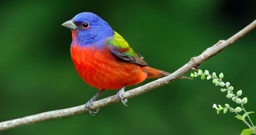

In [6]:
from fastdownload import download_url
dest = 'bird.jpg'
download_url(urls[0], dest, show_progress=False)

from fastai.vision.all import *
im = Image.open(dest)
im.to_thumb(256,256)

Now let's do the same with "forest photos":

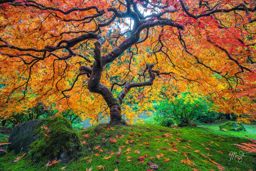

In [7]:
download_url(search_images('forest photos', max_images=1)[0], 'forest.jpg', show_progress=False)
# download_url(forest_urls[0], 'forest.jpg', show_progress=False) # hardcoded since DDGS search is rate limiting badly. (i think we might need to run locally)
Image.open('forest.jpg').to_thumb(256,256)

Our searches seem to be giving reasonable results, so let's grab a few examples of each of "bird" and "forest" photos, and save each group of photos to a different folder:

In [8]:
searches = 'forest','bird'
path = Path('bird_or_not')

for o in searches:
    dest = (path/o)
    dest.mkdir(exist_ok=True, parents=True)
    download_images(dest, urls=search_images(f'{o} photo'))
    time.sleep(5)
    resize_images(path/o, max_size=400, dest=path/o)

## Step 2: Train our model

Some photos might not download correctly which could cause our model training to fail, so we'll remove them:

In [9]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

0

In [10]:
import os
print(path)
print(os.listdir(path))

# import os
print("bird:", len(os.listdir(path/'bird')))
print("forest:", len(os.listdir(path/'forest')))

bird_or_not
['forest', 'bird']
bird: 9
forest: 10


To train a model, we'll need `DataLoaders`, which is an object that contains a *training set* (the images used to create a model) and a *validation set* (the images used to check the accuracy of a model -- not used during training). In `fastai` we can create that easily using a `DataBlock`, and view sample images from it:

In [11]:
search_terms = {
    'bird': ['bird photo', 'bird flying', 'bird perched', 'parrot photo', 'eagle photo'],
    'forest': ['forest photo', 'forest trees', 'woodland photo', 'jungle photo', 'rainforest'],
}

for label, terms in search_terms.items():
    dest = path/label
    dest.mkdir(parents=True, exist_ok=True)
    for term in terms:
        urls = search_images(term, max_images=20)
        print(f"'{term}': {len(urls)} urls")
        for i, url in enumerate(urls):
            fname = dest/f"{term.replace(' ','_')}_{i:04d}.jpg"
            if fname.exists(): continue
            try:
                download_url(url, fname, show_progress=False, timeout=5)
            except Exception as e:
                print(f"  skipped: {e}")

# verify and remove corrupted
from fastai.vision.all import *
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
print(f"Removed {len(failed)} corrupted images")

# final count
for label in ['bird', 'forest']:
    print(f"{label}: {len(list((path/label).iterdir()))}")

'bird photo': 20 urls
  skipped: HTTP Error 403: Forbidden
====Error Body====
<!DOCTYPE html><html lang="en-US"><head><title>Just a moment...</title><meta http-equiv="Content-Type" content="text/html; charset=UTF-8"><meta http-equiv="X-UA-Compatible" content="IE=Edge"><meta name="robots" content="noindex,nofollow"><meta name="viewport" content="width=device-width,initial-scale=1"><meta http-equiv="content-security-policy" content="default-src &#39;none&#39;; script-src &#39;nonce-joGZOzI0f6oYY8nmV0JP1s&#39; &#39;unsafe-eval&#39; https://challenges.cloudflare.com; script-src-attr &#39;none&#39;; style-src &#39;unsafe-inline&#39;; img-src &#39;self&#39; https://challenges.cloudflare.com; connect-src &#39;self&#39; https://challenges.cloudflare.com; frame-src &#39;self&#39; https://challenges.cloudflare.com blob:; child-src &#39;self&#39; https://challenges.cloudflare.com blob:; worker-src blob:; form-action http: https:; base-uri &#39;self&#39;"><style>*{box-sizing:border-box;margin:0;pa

In [ ]:
import torch
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("M3 Max GPU (Metal) is active! 🚀")
else:
    print("Using CPU. (Check your install)")

M3 Max GPU (Metal) is active! 🚀


In [ ]:
# for online, use this, else for local MAC, use above mps check
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")
print(torch.__version__)

False
No GPU
2.11.0


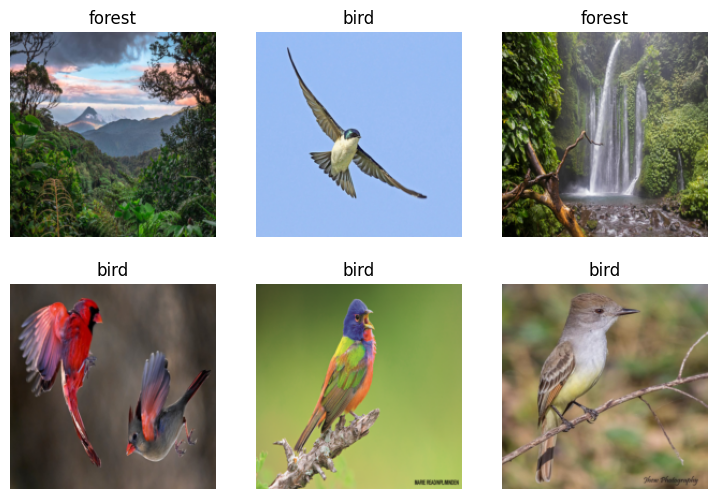

In [13]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, bs=32)

dls.show_batch(max_n=6)

Here what each of the `DataBlock` parameters means:

    blocks=(ImageBlock, CategoryBlock),

The inputs to our model are images, and the outputs are categories (in this case, "bird" or "forest").

    get_items=get_image_files, 

To find all the inputs to our model, run the `get_image_files` function (which returns a list of all image files in a path).

    splitter=RandomSplitter(valid_pct=0.2, seed=42),

Split the data into training and validation sets randomly, using 20% of the data for the validation set.

    get_y=parent_label,

The labels (`y` values) is the name of the `parent` of each file (i.e. the name of the folder they're in, which will be *bird* or *forest*).

    item_tfms=[Resize(192, method='squish')]

Before training, resize each image to 192x192 pixels by "squishing" it (as opposed to cropping it).

Now we're ready to train our model. The fastest widely used computer vision model is `resnet18`. You can train this in a few minutes, even on a CPU! (On a GPU, it generally takes under 10 seconds...)

`fastai` comes with a helpful `fine_tune()` method which automatically uses best practices for fine tuning a pre-trained model, so we'll use that.

In [14]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(3)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/pbhaskal/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:12<00:00, 3.65MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,0.680847,0.189045,0.121951,00:11


epoch,train_loss,valid_loss,error_rate,time
0,0.096767,0.009466,0.000000,00:06
1,0.050101,0.000764,0.000000,00:05
2,0.032843,0.000287,0.000000,00:05


Generally when I run this I see 100% accuracy on the validation set (although it might vary a bit from run to run).

"Fine-tuning" a model means that we're starting with a model someone else has trained using some other dataset (called the *pretrained model*), and adjusting the weights a little bit so that the model learns to recognise your particular dataset. In this case, the pretrained model was trained to recognise photos in *imagenet*, and widely-used computer vision dataset with images covering 1000 categories) For details on fine-tuning and why it's important, check out the [free fast.ai course](https://course.fast.ai/).

## Step 3: Use our model (and build your own!)

Let's see what our model thinks about that bird we downloaded at the start:

In [15]:
is_bird,_,probs = learn.predict(PILImage.create('bird.jpg'))
print(f"This is a: {is_bird}.")
print(f"Probability it's a bird: {probs[0]:.4f}")

This is a: bird.
Probability it's a bird: 1.0000


Test function to download a url and tell if it is bird or not.


In [16]:
from fastai.vision.all import *
from fastdownload import download_url
from pathlib import Path

def testImage(image_path_or_url: str):
    # --- load from URL or local path ---
    if str(image_path_or_url).startswith("http"):
        try:
            download_url(image_path_or_url, 'test.jpg', show_progress=False)
        except Exception as e:
            print(f"Failed to download image: {e}")
            return
        img_path = Path('test.jpg')
    else:
        img_path = Path(image_path_or_url)
        if not img_path.exists():
            print(f"File not found: {img_path}")
            return

    # --- resize and show ---
    # img.to_thumb(192).show()
    print(f"image url: {img_path}")
    # Image.open(img_path).to_thumb(256,256)

    # --- verify it's a valid image ---
    try:
        img = PILImage.create(img_path)
    except Exception as e:
        print(f"Could not open image: {e}")
        return



    # --- predict ---
    try:
        is_bird, _, probs = learn.predict(img)
    except Exception as e:
        print(f"Prediction failed: {e}")
        return

    print(f"This is a: {is_bird}.")
    print(f"Probability it's a bird: {probs[0]:.4f}")
    print(f"Probability it's a forest: {probs[1]:.4f}")

    return img.to_thumb(192)

use above test function to donwload and predict, also print (kaggle prints the last return data so we need to return image in function)

image url: test.jpg


This is a: bird.
Probability it's a bird: 0.9970
Probability it's a forest: 0.0030


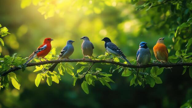

In [21]:
# download image https://static.vecteezy.com/system/resources/thumbnails/049/201/490/small/colorful-birds-perched-on-branches-surrounded-by-lush-greenery-during-a-golden-hour-in-nature-photo.jpeg
# test with model
test_url="https://static.vecteezy.com/system/resources/thumbnails/049/201/490/small/colorful-birds-perched-on-branches-surrounded-by-lush-greenery-during-a-golden-hour-in-nature-photo.jpeg"
# test_url="https://static.vecteezy.com/system/resources/thumbnails/035/426/687/small/ai-generated-explore-the-coevolutionary-relationships-between-specific-tree-species-and-the-colorful-birds-highlighting-how-each-has-shaped-the-other-s-characteristics-over-time-photo.jpg"
# test_url="https://earth.org/wp-content/uploads/2022/02/1-3.jpg"
# test_url="https://www.beautifulworld.com/wp-content/uploads/2016/10/amazon-rainforest.jpg"
testImage(test_url)

Good job, resnet18. :)

So, as you see, in the space of a few years, creating computer vision classification models has gone from "so hard it's a joke" to "trivially easy and free"!

It's not just in computer vision. Thanks to deep learning, computers can now do many things which seemed impossible just a few years ago, including [creating amazing artworks](https://openai.com/dall-e-2/), and [explaining jokes](https://www.datanami.com/2022/04/22/googles-massive-new-language-model-can-explain-jokes/). It's moving so fast that even experts in the field have trouble predicting how it's going to impact society in the coming years.

One thing is clear -- it's important that we all do our best to understand this technology, because otherwise we'll get left behind!

Now it's your turn. Click "Copy & Edit" and try creating your own image classifier using your own image searches!

If you enjoyed this, please consider clicking the "upvote" button in the top-right -- it's very encouraging to us notebook authors to know when people appreciate our work.